In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set()

In [3]:
df = pd.read_csv(r"D:\Div\turboaz_data_cleaning\turboaz_cars_cleaned_iqr.csv")

In [4]:
df.shape

(228236, 33)

In [5]:
df.columns

Index(['city', 'day', 'hour', 'engine_displacement_num', 'kilometrage_num',
       'barter', 'loan', 'salon', 'vip', 'featured', 'price', 'currency',
       'shop_name', 'views', 'ban_type', 'production_year', 'market_type',
       'Marka', 'Model', 'Qəzalı', 'Rəng', 'Sahiblər', 'transmission',
       'Vəziyyəti', 'Yeni', 'seat_count', 'drivetrain', 'at_gucu',
       'yanacaq_novu', 'Kondisioner', 'Arxa_kamera', 'Rənglənib', 'price_azn'],
      dtype='str')

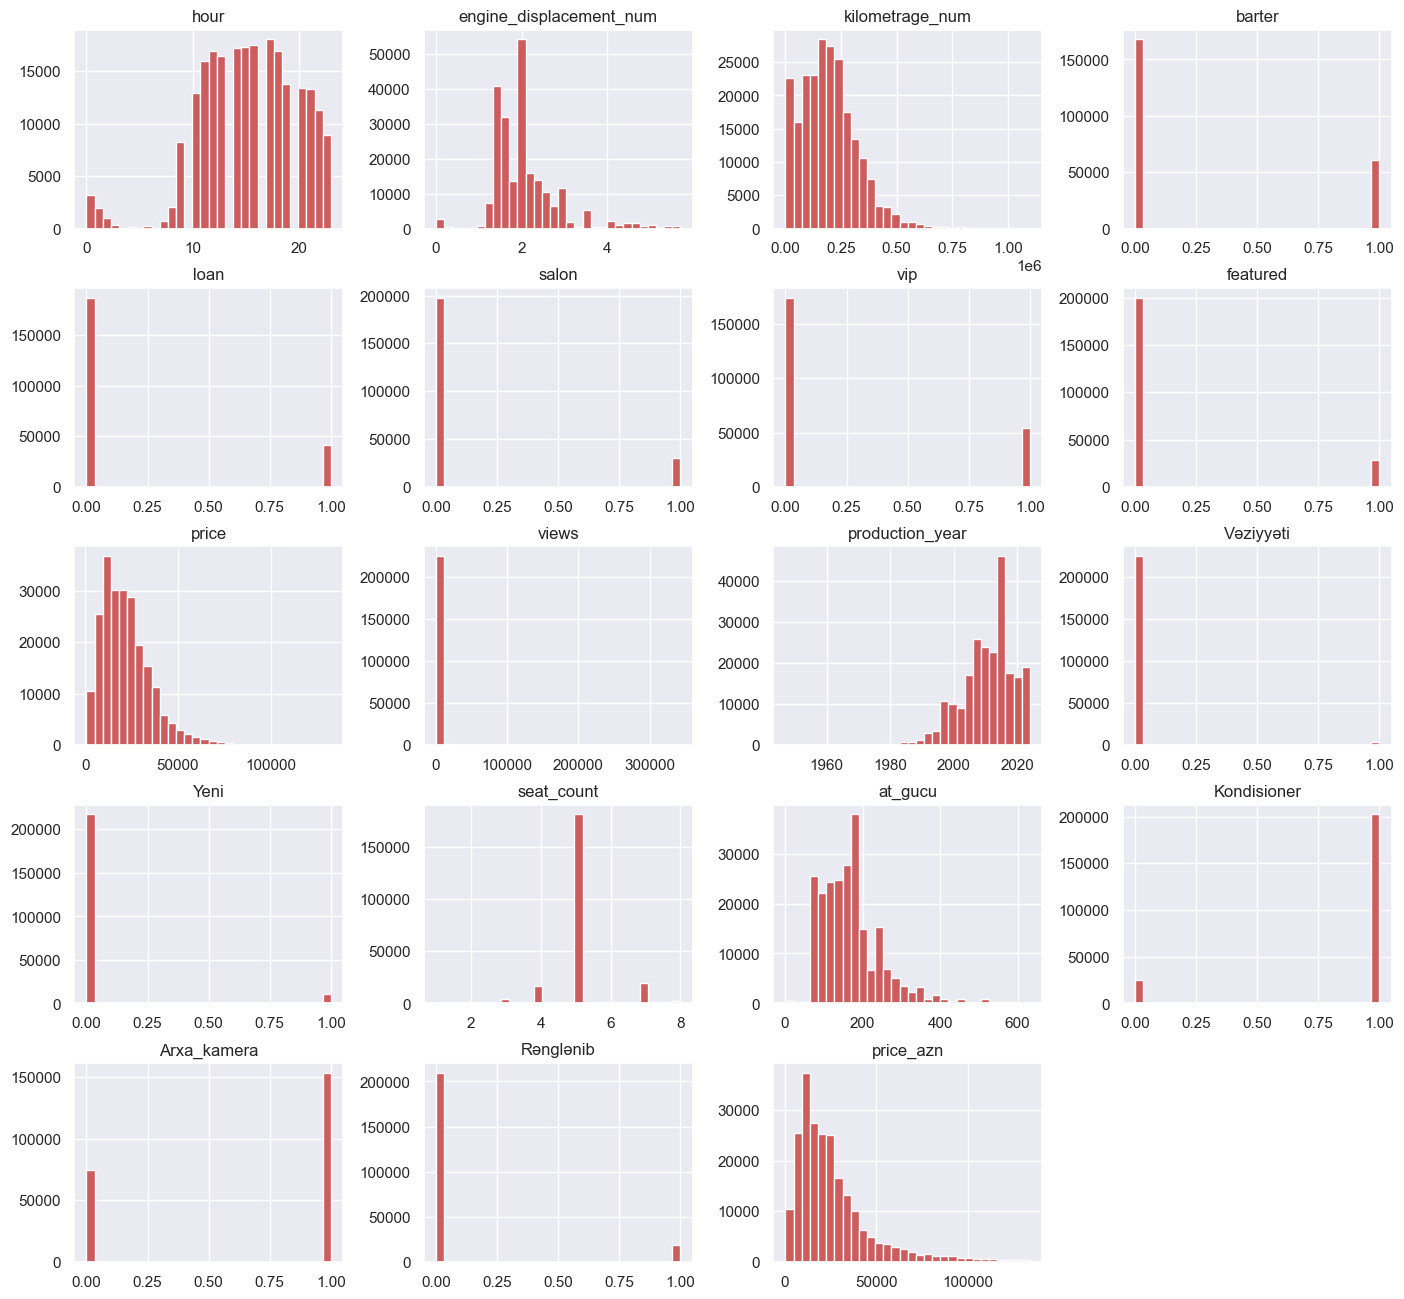

In [4]:
df.hist(bins=30,figsize=(17,16),color='indianred')
plt.show();

In [6]:
marka10 = df["Marka"].value_counts().head(10)

In [7]:
marka10.values

array([36204, 31424, 24089, 23772, 16669, 15301,  9460,  9348,  9314,
        7987])

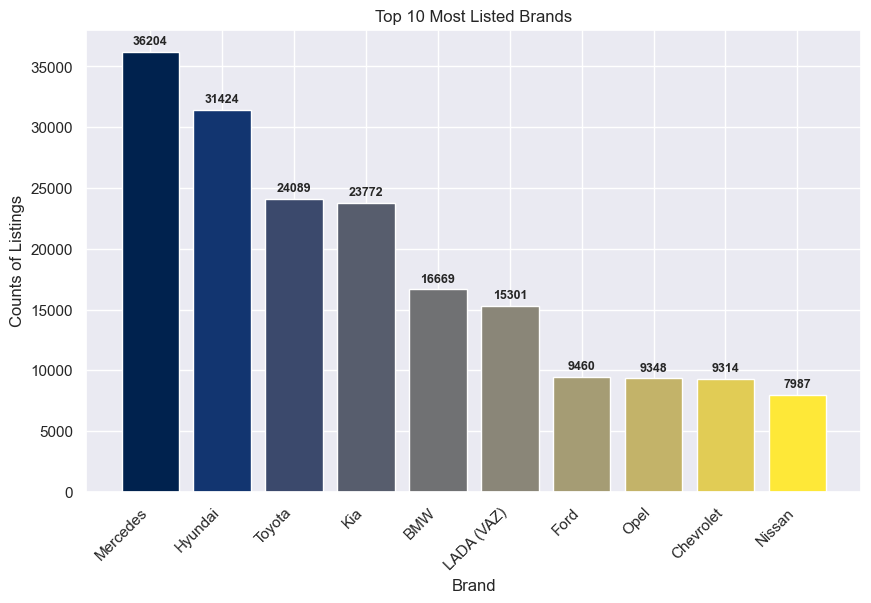

In [8]:
plt.figure(figsize=(10, 6))
colors = plt.cm.cividis(np.linspace(0, 1, len(marka10)))
bar = plt.bar(x=marka10.index, height=marka10.values, color =colors)
plt.bar_label(bar, padding=3, fontsize= 9, fontweight='bold')
plt.title("Top 10 Most Listed Brands")
plt.xlabel("Brand")
plt.ylabel("Counts of Listings")
plt.xticks(rotation=45, ha='right')
plt.show();

In [9]:
top10_marka = df.groupby('Marka')['price_azn'].mean()[df.groupby('Marka')['price_azn'].mean().index.isin(df["Marka"].value_counts().head(10).index)]

In [10]:
top10_marka

Marka
BMW           35551.036625
Chevrolet     17243.040133
Ford          22166.301321
Hyundai       25002.181906
Kia           27452.736808
LADA (VAZ)     7672.059081
Mercedes      24510.252173
Nissan        17988.891399
Opel           9341.111147
Toyota        32483.455456
Name: price_azn, dtype: float64

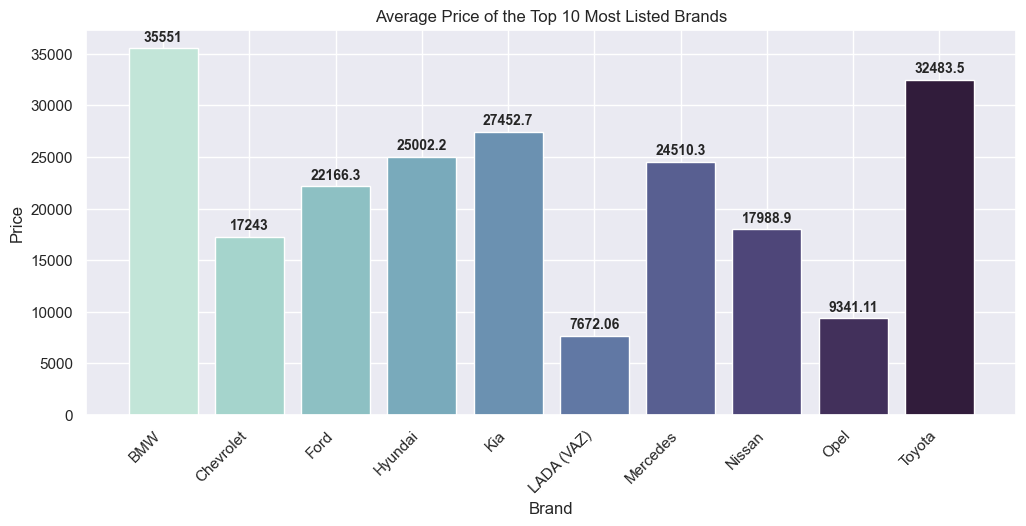

In [11]:
plt.figure(figsize=(12,5))
cmap = custom_palette = sns.cubehelix_palette(n_colors=len(top10_marka), start=.5, rot=-.5)

bar = plt.bar(x=top10_marka.index, height=top10_marka.values,color=cmap)
plt.bar_label(bar, padding=3, fontsize=10, fontweight='bold')

plt.title("Average Price of the Top 10 Most Listed Brands")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.xticks(rotation=45, ha='right')
plt.show;



In [12]:
df.columns

Index(['city', 'day', 'hour', 'engine_displacement_num', 'kilometrage_num',
       'barter', 'loan', 'salon', 'vip', 'featured', 'price', 'currency',
       'shop_name', 'views', 'ban_type', 'production_year', 'market_type',
       'Marka', 'Model', 'Qəzalı', 'Rəng', 'Sahiblər', 'transmission',
       'Vəziyyəti', 'Yeni', 'seat_count', 'drivetrain', 'at_gucu',
       'yanacaq_novu', 'Kondisioner', 'Arxa_kamera', 'Rənglənib', 'price_azn'],
      dtype='str')

In [13]:
top_models = df['Model'].value_counts().head(10).index

model_loan = (
    df[df['Model'].isin(top_models)]
    .groupby(['Model', 'loan'])
    .size()
    .reset_index(name='Listing Count')
)

In [14]:
model_loan

,Model,loan,Listing Count
0,2107,0,4065
1,2107,1,447
2,Astra,0,5810
3,Astra,1,729
4,Cruze,0,3767
5,Cruze,1,891
6,E 220 d,0,3829
7,E 220 d,1,743
8,Elantra,0,5560
9,Elantra,1,1397


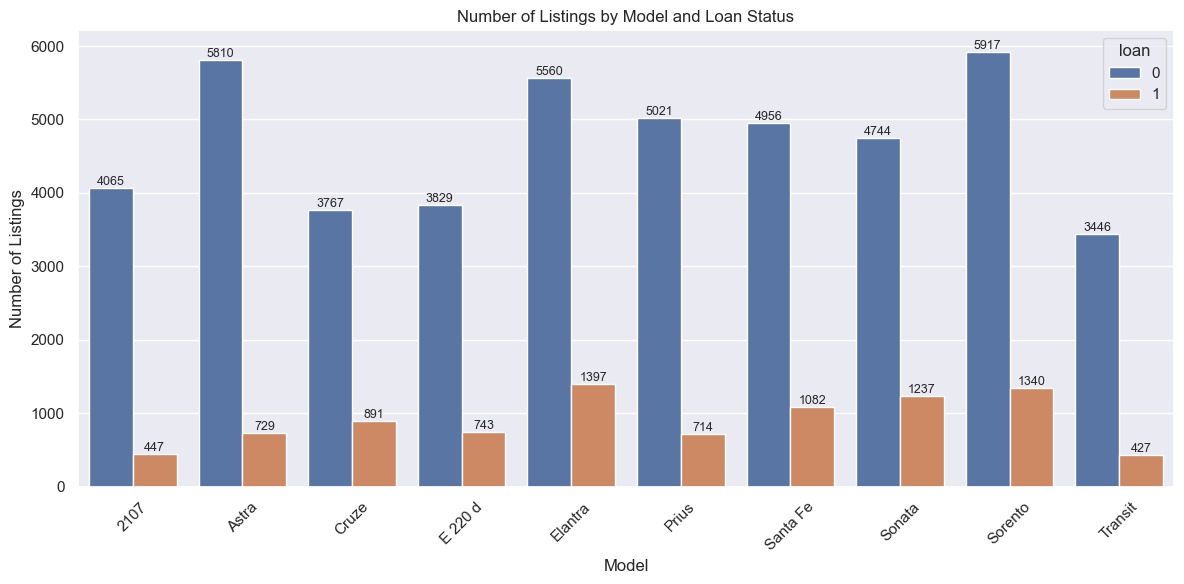

In [15]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=model_loan,
    x='Model',
    y='Listing Count',
    hue='loan'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9)

plt.title('Number of Listings by Model and Loan Status')
plt.xlabel('Model')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
df_avg = df.groupby('hour')['views'].mean().reset_index()


In [17]:
fig = px.line(
    df_avg, 
    x='hour', 
    y='views', 
    title="<b>Views distribution by hour</b>",
    labels={'hour': 'Hour', 'views': 'Count of Average Views'}
)
fig.update_traces(
    line=dict(color='teal', width=3),
    mode='lines+markers' )

fig.update_layout(
    xaxis=dict(
        tickmode='linear',
        tick0=0,
        dtick=1 
    ),
    template='plotly_white', 
    width=1000,
    height=500
)

fig.show();

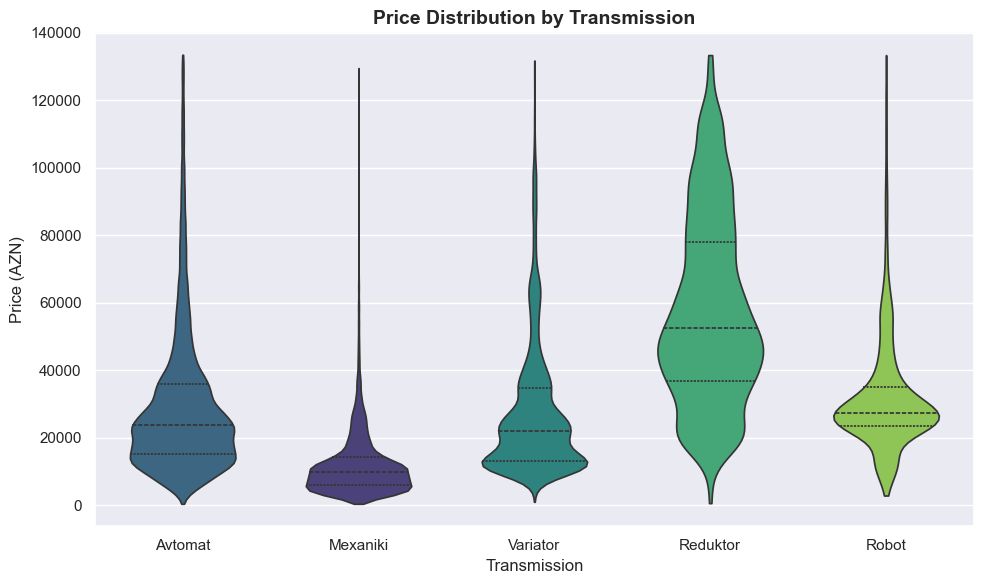

In [18]:
plt.figure(figsize=(10, 6))

order = df['transmission'].value_counts().index

sns.violinplot(
    data=df,
    x='transmission',
    y='price_azn',
    order=order,
    palette='viridis',
    hue='transmission',
    legend=False,
    inner='quartile',   # median və kvartilləri göstərir
    cut=0,
    width=0.6
)

plt.title('Price Distribution by Transmission', fontsize=14, fontweight='bold')
plt.xlabel('Transmission')
plt.ylabel('Price (AZN)')

plt.tight_layout()
plt.show()

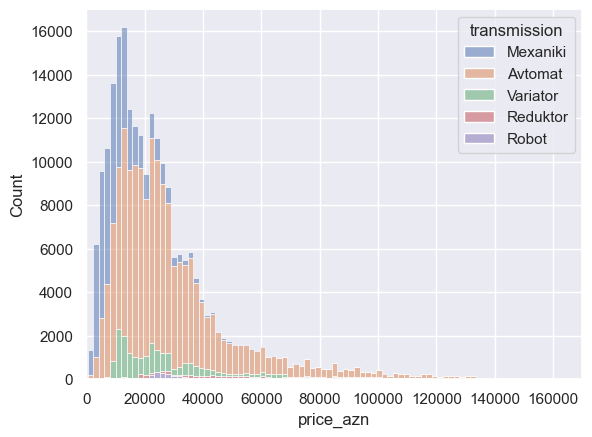

In [19]:
sns.histplot(data=df, x='price_azn', hue='transmission',bins=70,multiple="stack",alpha=0.5)
plt.xlim(0, 170000)  
plt.show()

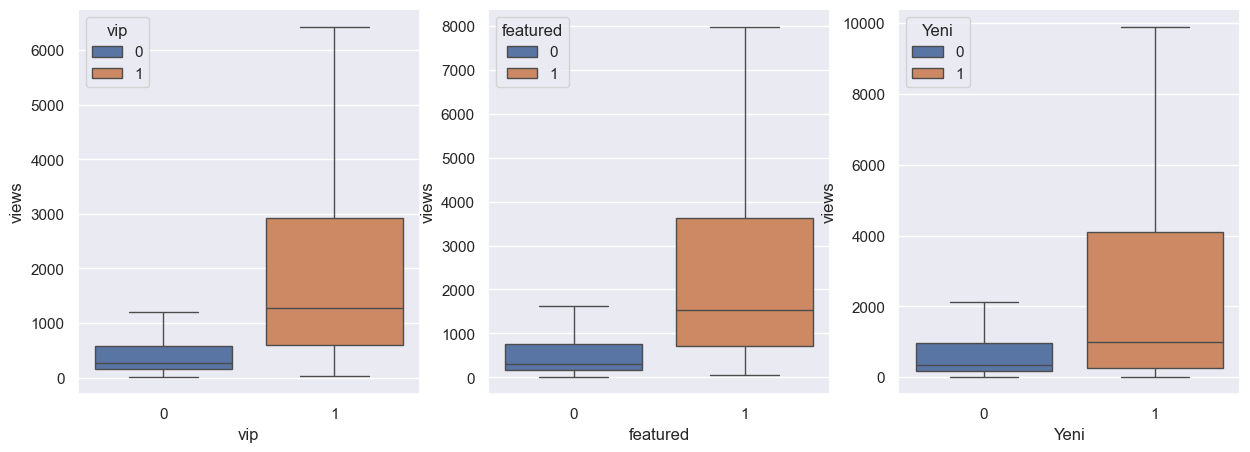

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cols = ['vip', 'featured', 'Yeni']

for i, col in enumerate(cols):
    sns.boxplot(
        data=df,
        x=col,
        y='views',
        ax=axes[i],
        hue=col,
        showfliers=False
    )

plt.show()

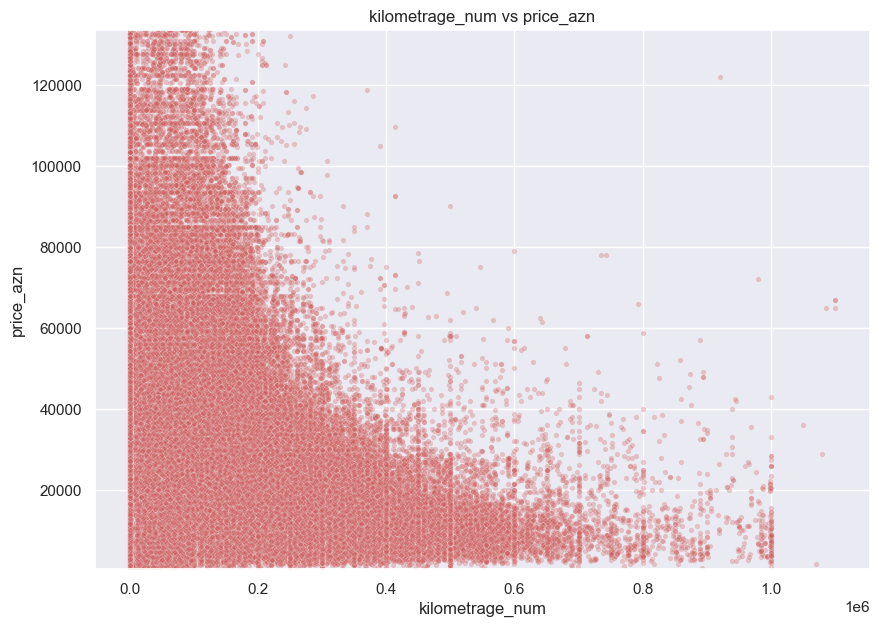

In [21]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='kilometrage_num', y='price_azn',
                 alpha=0.3, s=15, color='indianred')
plt.title('kilometrage_num vs price_azn' )
plt.ylim(df['price_azn'].min(),df['price_azn'].max())
plt.show()

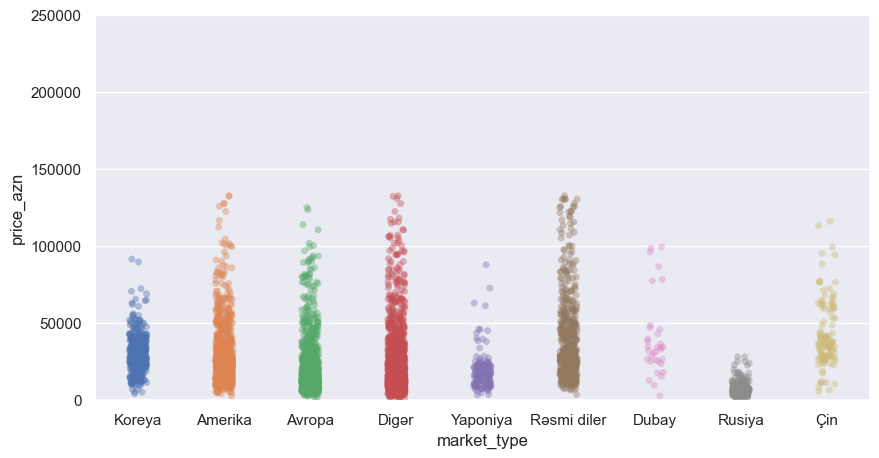

In [22]:
plt.figure(figsize=(10,5))
sns.stripplot(
    data=df.sample(5000),
    x='market_type',
    y='price_azn',
    alpha=0.4,
    hue='market_type'
    
)
plt.ylim(0,250000)
plt.show()

In [24]:
median_price_brand=df.groupby('Marka')['price_azn'].median().sort_values(ascending=False).head(15)
median_price_brand

Marka
Mercedes-Maybach     122400.0
Bentley              119000.0
Seres Aito           107610.0
Denza                101800.0
Li Auto               96050.0
IM                    90610.0
ROX (Polar Stone)     90098.3
Seres                 88400.0
Nio                   84150.0
Avatr                 83298.3
XPeng                 81430.0
Voyah                 76330.0
Xiaomi                74460.0
ZEEKR                 71400.0
Indian Motorcycle     68850.0
Name: price_azn, dtype: float64

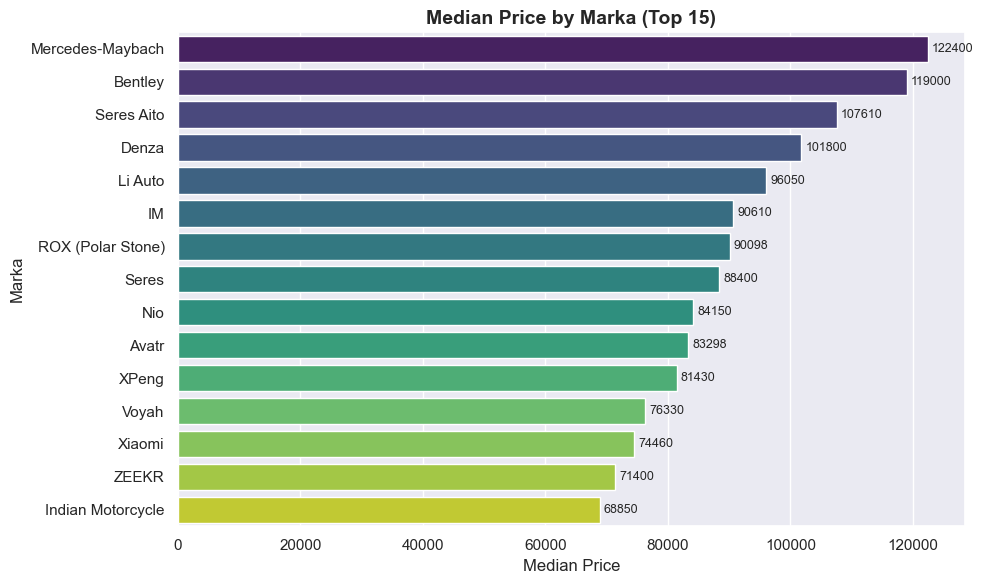

In [25]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=median_price_brand.values,
    y=median_price_brand.index,
    hue=median_price_brand.index,
    palette='viridis',
    legend=False
)

# Rəqəmləri sütunların sonunda göstər
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',      # tam ədəd kimi
        padding=3,
        fontsize=9
    )

plt.title('Median Price by Marka (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Median Price')
plt.ylabel('Marka')

plt.tight_layout()
plt.show()

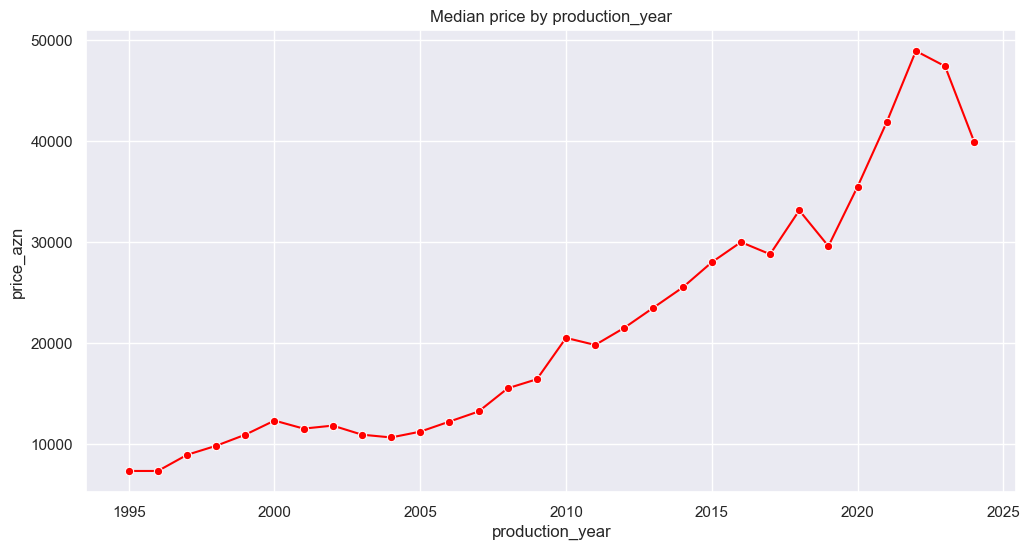

In [26]:
yearly_price = df.groupby('production_year')['price_azn'].median().reset_index()
yearly_price = yearly_price[yearly_price['production_year'] >= 1995]

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_price, x='production_year', y='price_azn',
             marker='o', color='red')
plt.title('Median price by production_year')

plt.show()